# 🎓 Student Performance & Placement — Story Notebook

This notebook walks through cleaning a raw student dataset, exploring it, handling outliers, building a simple linear regression model to predict placement salary (`LPA`) from `Exam_Score`, evaluating it with multiple metrics (R², Adjusted R², MSE, RMSE, MAE, MAPE), and finally running two feature-engineering experiments.

**How to use this notebook:** each section poses a question describing what the code should do. Write the code yourself in the empty cell below the question. Where a step already has code filled in, that's a completed exercise — feel free to re-derive it yourself first, then compare.

*(Dataset: `student_raw_dataset.csv`)*

### 🧩 Step 1 — Set Up Your Toolkit
Before touching the data, import the libraries you'll need:
- `numpy` and `pandas` for data handling
- `matplotlib.pyplot` for plotting
- `StandardScaler` from `sklearn.preprocessing` for later scaling

Also fix the random seed to **42** so your results are reproducible every time you rerun the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

### 🧩 Step 2 — Load the Dataset
Read `student_raw_dataset.csv` into a pandas DataFrame called `df`.

In [2]:
df = pd.read_csv("student_raw_dataset.csv")

### 🧩 Step 3 — First Look at the Data
Display the first 5 rows of `df` so you can see what the columns look like, and check the overall shape (number of rows and columns) of the dataset.

In [3]:
display(df.head())
df.shape

,Student_ID,Name,Age,Gender,Prayers_Before_Exams,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Entrance_Exam_Score,Rank,Placement,LPA
0,ST001,Rina Bhat,17,Female,Yes,Information Technology,7,75,14,62.38,Pass,B,186,316,Placed,5.21
1,ST002,Aika Sethi,19,Male,No,Electronics,5,99,11,63.49,Pass,B,190,289,Placed,5.87
2,ST003,Takeru Khan,19,Female,No,Computer Science,7,89,14,65.81,Pass,B,196,263,Placed,4.47
3,ST004,Marina Bansal,19,Male,No,Electronics,0,83,3,17.27,Fail,F,57,593,Not Placed,0.00
4,ST005,Honoka Patil,19,Male,No,Mechanical,8,80,20,95.79,Pass,A+,294,7,Placed,9.34


(600, 16)

### 🧩 Step 4 — Spot the Problems
Before cleaning anything, investigate what's wrong with the data:
1. Print the count of missing values for every column.
2. Count how many rows have a **negative** `Study_Hours` value (which shouldn't be possible).
3. Print summary statistics (`describe`, including non-numeric columns) to get a feel for the ranges and distributions.

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nNegative Study Hours:")
print((df["Study_Hours"] < 0).sum())

print("\nBasic Statistics:")
df.describe(include="all")

Missing Values:
Student_ID              0
Name                    0
Age                     0
Gender                  0
Prayers_Before_Exams    0
Department              3
Study_Hours             0
Attendance              0
Assignments             0
Exam_Score              3
Result                  0
Grade                   0
Entrance_Exam_Score     0
Rank                    0
Placement               0
LPA                     3
dtype: int64

Negative Study Hours:
3

Basic Statistics:


,Student_ID,Name,Age,Gender,Prayers_Before_Exams,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Entrance_Exam_Score,Rank,Placement,LPA
count,600,600,600.000000,600,600,597,600.000000,600.000000,600.000000,597.000000,600,600,600.000000,600.000000,600,597.000000
unique,600,582,NaN,2,2,4,NaN,NaN,NaN,NaN,2,6,NaN,NaN,2,NaN
top,ST001,Miku Kumar,NaN,Male,No,Computer Science,NaN,NaN,NaN,NaN,Pass,B,NaN,NaN,Not Placed,NaN
freq,1,3,NaN,365,353,184,NaN,NaN,NaN,NaN,537,151,NaN,NaN,317,NaN
mean,NaN,NaN,18.420000,NaN,NaN,NaN,5.131667,81.401667,13.161667,62.086834,NaN,NaN,186.473333,300.500000,NaN,3.141675
std,NaN,NaN,0.870745,NaN,NaN,NaN,2.120178,9.422932,3.732571,17.105282,NaN,NaN,51.963509,173.349358,NaN,3.960196
min,NaN,NaN,17.000000,NaN,NaN,NaN,-3.000000,60.000000,1.000000,8.290000,NaN,NaN,27.000000,1.000000,NaN,0.000000
25%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,74.000000,11.000000,52.440000,NaN,NaN,156.750000,150.750000,NaN,0.000000
50%,NaN,NaN,18.000000,NaN,NaN,NaN,5.000000,81.000000,13.000000,62.580000,NaN,NaN,189.000000,300.500000,NaN,0.000000
75%,NaN,NaN,19.000000,NaN,NaN,NaN,7.000000,89.000000,16.000000,74.020000,NaN,NaN,221.250000,450.250000,NaN,5.760000


### 🧩 Step 5 — Visualize Before Cleaning
Make a scatter plot of `Exam_Score` (x-axis) vs `LPA` (y-axis) to see what the raw, uncleaned relationship looks like. Label both axes and give the plot a title like *"Exam Score vs LPA - Before Pre-processing"*.

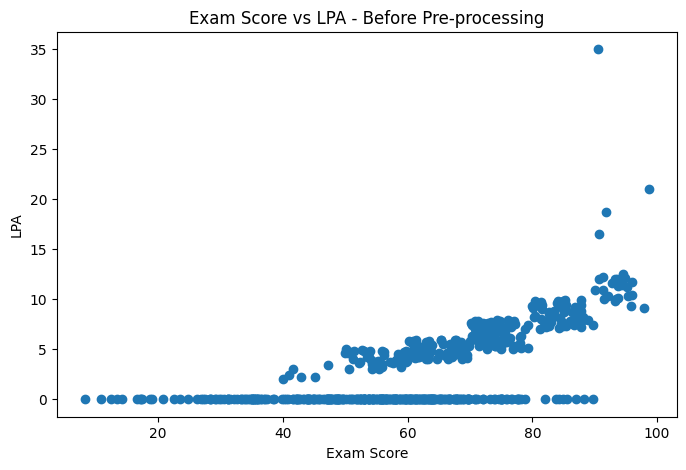

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Exam_Score"], df["LPA"])
plt.xlabel("Exam Score")
plt.ylabel("LPA")
plt.title("Exam Score vs LPA - Before Pre-processing")
plt.show()

### 🧩 Step 6 — Fix Negative Study Hours
`Study_Hours` can't logically be negative.
1. Take only the valid (non-negative) `Study_Hours` values and compute their **median**.
2. Replace every negative `Study_Hours` value in `df` with that median.
3. Print the median you used, and confirm no negative values remain.

In [6]:
valid_study_hours = df.loc[df["Study_Hours"] >= 0, "Study_Hours"]

study_hours_median = valid_study_hours.median()

df.loc[df["Study_Hours"] < 0, "Study_Hours"] = study_hours_median

print("Median valid Study Hours:", study_hours_median)
print("Remaining negative values:",
      (df["Study_Hours"] < 0).sum())

Median valid Study Hours: 5.0
Remaining negative values: 0


### 🧩 Step 7 — Fill Missing Departments
The `Department` column has a few missing values.
1. Find the most frequent department (the **mode**).
2. Fill the missing `Department` entries with that mode.
3. Print the mode you used and confirm no missing values remain in `Department`.

In [7]:
department_mode = df["Department"].mode()[0]

df["Department"] = df["Department"].fillna(department_mode)

print("Department mode:", department_mode)
print("Remaining missing Department:",
      df["Department"].isnull().sum())

Department mode: Computer Science
Remaining missing Department: 0


### 🧩 Step 8 — Fill Missing Exam Scores
`Exam_Score` also has a few missing values.
1. Compute the **median** `Exam_Score`.
2. Fill the missing entries with that median.
3. Print the median used and confirm no missing values remain.

In [8]:
exam_score_median = df["Exam_Score"].median()

df["Exam_Score"] = df["Exam_Score"].fillna(exam_score_median)

print("Exam Score median:", exam_score_median)
print("Remaining missing Exam Score:",
      df["Exam_Score"].isnull().sum())

Exam Score median: 62.58
Remaining missing Exam Score: 0


### 🧩 Step 9 — Fill Missing LPA (Only for Placed Students)
Some students marked `Placement == "Placed"` are missing an `LPA` (salary) value — but it wouldn't make sense to fill *all* missing LPAs the same way, since "Not Placed" students have no salary at all.
1. Compute the median `LPA` **only among placed students who have a valid LPA**.
2. Fill in the missing `LPA` values **only for placed students** using that median.
3. Print the median used and confirm no missing `LPA` values remain among placed students.

In [9]:
placed_lpa_median = df.loc[
    (df["Placement"] == "Placed") & df["LPA"].notna(),
    "LPA"
].median()

missing_placed_lpa = (
    (df["Placement"] == "Placed") &
    (df["LPA"].isna())
)

df.loc[missing_placed_lpa, "LPA"] = placed_lpa_median

print("Placed-student LPA median:", placed_lpa_median)
print("Remaining missing LPA:",
      df["LPA"].isnull().sum())

Placed-student LPA median: 5.94
Remaining missing LPA: 0


### 🧩 Step 10 — Visualize Department Distribution
Plot a bar chart showing how many students belong to each `Department`, with an appropriate title.

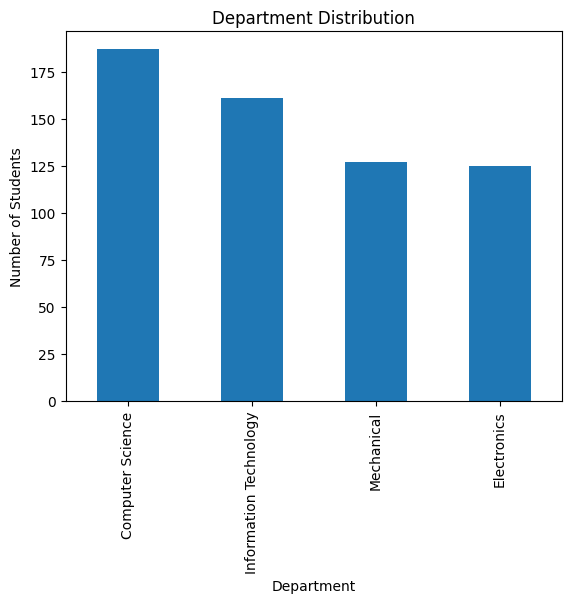

In [10]:
df["Department"].value_counts().plot(kind="bar", title="Department Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.show()

### 🧩 Step 11 — Compare Average Salaries Across Departments
Group the data by `Department` and compute, for each department's `LPA`:
- number of students (`Total_Students`)
- average salary (`Avg_Salary`)
- median salary (`Median_Salary`)
- minimum salary (`Min_Salary`)
- maximum salary (`Max_Salary`)
- standard deviation of salary (`Salary_Std`)

Sort the result by `Avg_Salary` in descending order and display it.

In [11]:
salary_stats = (
    df.groupby("Department", as_index=False)["LPA"]
      .agg(
          Total_Students=("count"),
          Avg_Salary=("mean"),
          Median_Salary=("median"),
          Min_Salary=("min"),
          Max_Salary=("max"),
          Salary_Std=("std")
      )
      .sort_values("Avg_Salary", ascending=False)
)

display(salary_stats)

,Department,Total_Students,Avg_Salary,Median_Salary,Min_Salary,Max_Salary,Salary_Std
1,Electronics,125,3.527680,3.62,0.0,16.50,4.021967
0,Computer Science,187,3.175401,0.00,0.0,21.00,3.785977
2,Information Technology,161,2.996149,0.00,0.0,18.75,3.759069
3,Mechanical,127,2.962677,0.00,0.0,35.00,4.374833


### 🧩 Step 12 — Re-import for the Outlier Analysis
Import `numpy` and `matplotlib.pyplot` again — you're about to move into the outlier-detection and modeling section of the notebook.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

### 🧩 Step 13 — Re-check the Exam Score vs LPA Relationship
Plot `Exam_Score` vs `LPA` one more time (on the cleaned data) to see how the relationship looks now, before you narrow down to placed students only. Label the axes (note the LPA axis anticipates a later Z-score cap) and title it accordingly.

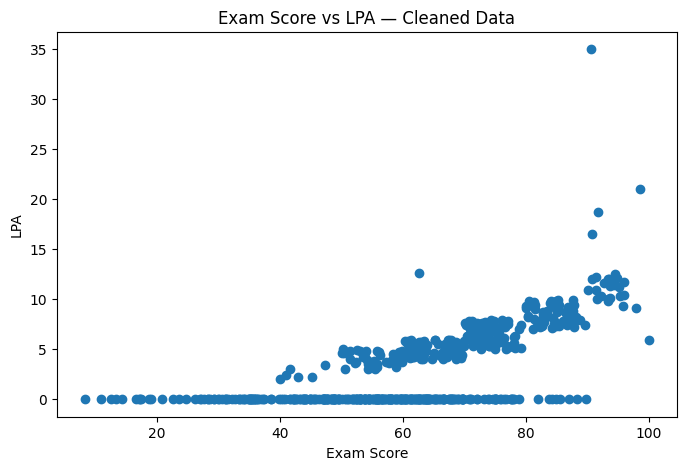

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Exam_Score"],
    df["LPA"]
)
plt.xlabel("Exam Score")
plt.ylabel("LPA")
plt.title("Exam Score vs LPA — Cleaned Data")
plt.show()

### 🧩 Step 14 — Focus on Placed Students
Only placed students have a meaningful `LPA`, so filter `df` down to a new DataFrame `df_placed` containing just the rows where `Placement == "Placed"`. Plot `Exam_Score` vs `LPA` for this subset, titled *"Exam Score vs LPA — Before Z-score Capping"*.

In [14]:
df_placed = df[df["Placement"] == "Placed"].copy()

print("Number of placed students:", len(df_placed))
display(df_placed.head())

Number of placed students: 283


,Student_ID,Name,Age,Gender,Prayers_Before_Exams,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Entrance_Exam_Score,Rank,Placement,LPA
0,ST001,Rina Bhat,17,Female,Yes,Information Technology,7,75,14,62.38,Pass,B,186,316,Placed,5.21
1,ST002,Aika Sethi,19,Male,No,Electronics,5,99,11,63.49,Pass,B,190,289,Placed,5.87
2,ST003,Takeru Khan,19,Female,No,Computer Science,7,89,14,65.81,Pass,B,196,263,Placed,4.47
4,ST005,Honoka Patil,19,Male,No,Mechanical,8,80,20,95.79,Pass,A+,294,7,Placed,9.34
6,ST007,Yoko Menon,20,Male,No,Mechanical,5,80,15,67.69,Pass,B,194,264,Placed,4.52


### 🧩 Step 15 — Detect and Cap Salary Outliers with Z-scores
Some placed students may have unusually high or low `LPA` values that could distort a regression model.
1. Use `StandardScaler` to compute the Z-score of `LPA` for `df_placed`, storing it in a new column `LPA_Z`.
2. Flag any row as an outlier if its `|Z-score|` is greater than 3.
3. Convert the ±3 Z-score boundary back into original `LPA` units using the scaler's mean and scale (`lower_cap`, `upper_cap`).
4. Create a new column `LPA_Capped` where any `LPA` beyond those bounds is clipped to the boundary.
5. Print how many outliers were found and show their `Student_ID`, `LPA`, `LPA_Z`, and `LPA_Capped`.
6. Plot `Exam_Score` vs `LPA_Capped` to see the effect of capping.

Number of Outliers: 4

Outliers:


,Student_ID,LPA,LPA_Z,LPA_Capped
123,ST124,35.00,9.203234,15.918587
348,ST349,18.75,3.920473,15.918587
381,ST382,21.00,4.651932,15.918587
570,ST571,16.50,3.189013,15.918587


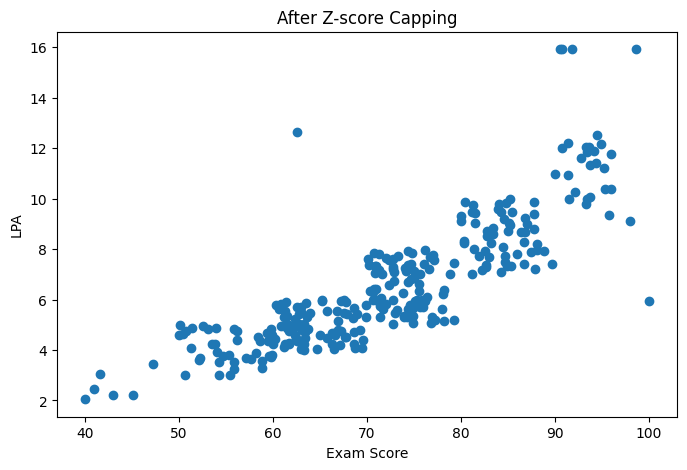

In [15]:
scaler = StandardScaler()
df_placed["LPA_Z"] = scaler.fit_transform(
    df_placed[["LPA"]]
).ravel()

outliers = df_placed["LPA_Z"].abs() > 3

lower_cap = scaler.mean_[0] - 3 * scaler.scale_[0]
upper_cap = scaler.mean_[0] + 3 * scaler.scale_[0]

df_placed["LPA_Capped"] = df_placed["LPA"].clip(
    lower=lower_cap,
    upper=upper_cap
)

print("Number of Outliers:", outliers.sum())
print("\nOutliers:")
display(
    df_placed.loc[
        outliers,
        ["Student_ID", "LPA", "LPA_Z", "LPA_Capped"]
    ]
)

plt.figure(figsize=(8, 5))
plt.scatter(df_placed["Exam_Score"], df_placed["LPA_Capped"])
plt.xlabel("Exam Score")
plt.ylabel("LPA")
plt.title("After Z-score Capping")
plt.show()

### 🧩 Step 16 — Import Your Modeling Tools
Import `train_test_split` (to split data), `LinearRegression` (the model), and `r2_score` (to evaluate it) from scikit-learn.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

### 🧩 Step 17 — Shuffle the Data
Randomly shuffle all rows of `df_placed` (using `frac=1` and a fixed `random_state=42` for reproducibility) and reset the index, so the train/test split isn't biased by any original ordering.

In [17]:
df_placed = df_placed.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

### 🧩 Step 18 — Choose Your Feature and Target
Define `X` as the feature the model will learn from (`Exam_Score`) and `y` as the target it should predict (`LPA_Capped`).

In [18]:
X = df_placed[["Exam_Score"]]
y = df_placed["LPA_Capped"]

### 🧩 Step 19 — Split into Train and Test Sets
Split `X` and `y` into training and test sets, holding out 20% of the data for testing, with `random_state=42` for reproducibility.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 226
Testing samples: 57


### 🧩 Step 20 — Train the Model
Create a `LinearRegression` model and fit it on the training data (`X_train`, `y_train`).

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: -5.240762489335184
Coefficient: 0.1630813893034318


### 🧩 Step 21 — Make Predictions
Use the trained model to predict `LPA` values for the test set (`X_test`).

In [21]:
y_pred = model.predict(X_test)

display(pd.DataFrame({
    "Actual_LPA": y_test.values,
    "Predicted_LPA": y_pred
}).head())

,Actual_LPA,Predicted_LPA
0,3.62,3.263932
1,3.03,1.549947
2,4.61,4.524551
3,7.84,6.967510
4,8.95,8.663557


### 🧩 Step 22 — Evaluate: R² Score
Calculate the R² score comparing the model's predictions (`y_pred`) against the actual test values (`y_test`).

In [22]:
r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.6736254169686544


### 🧩 Step 23 — Prep for Adjusted R²
Adjusted R² needs two extra numbers: the number of test samples (`n`, the length of `y_test`) and the number of features used by the model (`p`, the number of columns in `X_test`).

In [23]:
n = len(y_test)
p = X_test.shape[1]

print("Number of test samples (n):", n)
print("Number of features (p):", p)

Number of test samples (n): 57
Number of features (p): 1


### 🧩 Step 24 — Evaluate: Adjusted R²
Using the formula

`Adjusted R² = 1 - [(1 - R²) * (n - 1) / (n - p - 1)]`

calculate the adjusted R² score, then print both the R² and adjusted R² values.

In [24]:
adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

R²: 0.6736254169686544
Adjusted R²: 0.6676913336408117


### 🧩 Step 25 — Evaluate: Mean Squared Error (MSE)
Calculate the Mean Squared Error (MSE) of the model's predictions (`y_pred`) against the actual test values (`y_test`).

In [25]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 2.850128673271772


### 🧩 Step 26 — Evaluate: Root Mean Squared Error (RMSE)
Calculate the Root Mean Squared Error (RMSE) of the model's predictions (`y_pred`) against the actual test values (`y_test`).

In [26]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1.6882324109173392


### 🧩 Step 27 — Evaluate: Mean Absolute Error (MAE)
Calculate the Mean Absolute Error (MAE) of the model's predictions (`y_pred`) against the actual test values (`y_test`).

In [27]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1.1160250168256167


### 🧩 Step 28 — Evaluate: Mean Absolute Percentage Error (MAPE)
Calculate the Mean Absolute Percentage Error (MAPE) of the model's predictions (`y_pred`) against the actual test values (`y_test`). Note that MAPE is sensitive to zero or near-zero actual values.

In [28]:
mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

print("Mean Absolute Percentage Error (MAPE):", mape, "%")

Mean Absolute Percentage Error (MAPE): 15.940012536590247 %


### 🧩 Step 29 — Experiment: Adding a Redundant Feature
Let's see how adding a redundant feature affects the model's performance metrics (R² and Adjusted R²). We will create a new feature that is a duplicate of `Exam_Score`.

In [29]:
# Create new feature sets with a redundant feature
X_train_redundant = X_train.copy()
X_train_redundant['Exam_Score_Grad'] = X_train['Exam_Score']/10

X_test_redundant = X_test.copy()
X_test_redundant['Exam_Score_Grad'] = X_test['Exam_Score']/10

# Train a new Linear Regression model with the redundant feature
model_redundant = LinearRegression()
model_redundant.fit(X_train_redundant, y_train)

# Make predictions
y_pred_redundant = model_redundant.predict(X_test_redundant)

# Calculate R²
r2_redundant = r2_score(y_test, y_pred_redundant)

# Calculate Adjusted R²
n_redundant = len(y_test) # Number of samples in test set
p_redundant = X_test_redundant.shape[1] # Number of features in test set (now 2)

adjusted_r2_redundant = 1 - ((1 - r2_redundant) * (n_redundant - 1) / (n_redundant - p_redundant - 1))

print(f"R² with Redundant Feature: {r2_redundant:.4f}")
print(f"Adjusted R² with Redundant Feature: {adjusted_r2_redundant:.4f}")

R² with Redundant Feature: 0.6736
Adjusted R² with Redundant Feature: 0.6615


### 🧩 Step 30 — Experiment: Adding a Useful Feature (Study_Hours)
Now, let's explore the effect of adding a potentially useful feature, `Study_Hours`, to our model. We expect this to improve the model's performance.

In [30]:
# Ensure df_placed has 'Study_Hours' and it's aligned with X_train/X_test
# We need to re-create X_train and X_test to include 'Study_Hours' from the original df_placed indices

# First, re-split the data to get the Study_Hours aligned correctly
# Assuming df_placed was shuffled and then split

# Get the indices from the original train/test split
train_indices = X_train.index
test_indices = X_test.index

# Create new feature sets including 'Study_Hours'
X_train_useful = df_placed.loc[train_indices, ['Exam_Score', 'Study_Hours']]
X_test_useful = df_placed.loc[test_indices, ['Exam_Score', 'Study_Hours']]

# Train a new Linear Regression model with the useful feature
model_useful = LinearRegression()
model_useful.fit(X_train_useful, y_train)

# Make predictions
y_pred_useful = model_useful.predict(X_test_useful)

# Calculate R²
r2_useful = r2_score(y_test, y_pred_useful)

# Calculate Adjusted R²
n_useful = len(y_test) # Number of samples in test set
p_useful = X_test_useful.shape[1] # Number of features in test set (now 2)

adjusted_r2_useful = 1 - ((1 - r2_useful) * (n_useful - 1) / (n_useful - p_useful - 1))

print(f"R² with Useful Feature (Study_Hours): {r2_useful:.4f}")
print(f"Adjusted R² with Useful Feature (Study_Hours): {adjusted_r2_useful:.4f}")

R² with Useful Feature (Study_Hours): 0.6788
Adjusted R² with Useful Feature (Study_Hours): 0.6669


In [33]:
display(pd.DataFrame({
    "Method": ["R2", "Adjusted - R2"],
    "Capped": [r2, adjusted_r2,],
    "Redundant": [r2_redundant, adjusted_r2_redundant],
    "Adding a Useful Feature": [r2_useful, adjusted_r2_useful]
}))

,Method,Capped,Redundant,Adding a Useful Feature
0,R2,0.673625,0.673625,0.678783
1,Adjusted - R2,0.667691,0.661537,0.666886
